In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df=pd.read_csv('StartUp.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [88]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [89]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [90]:
correlations=df.drop("State",axis=1).corr()
correlations

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

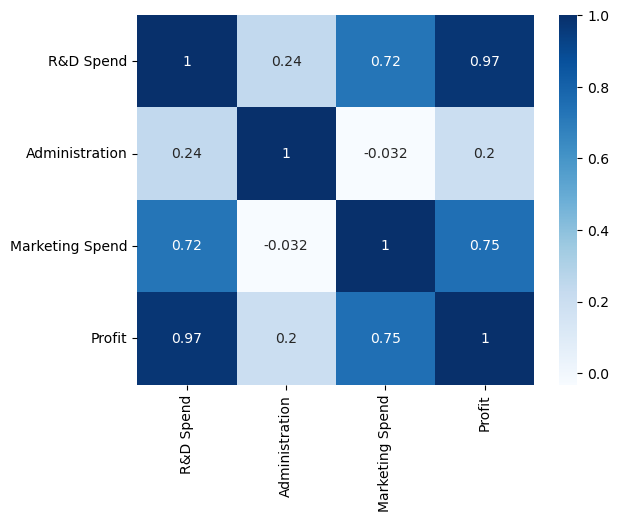

In [91]:
sns.heatmap(correlations, annot=True, cmap="Blues")

<Axes: >

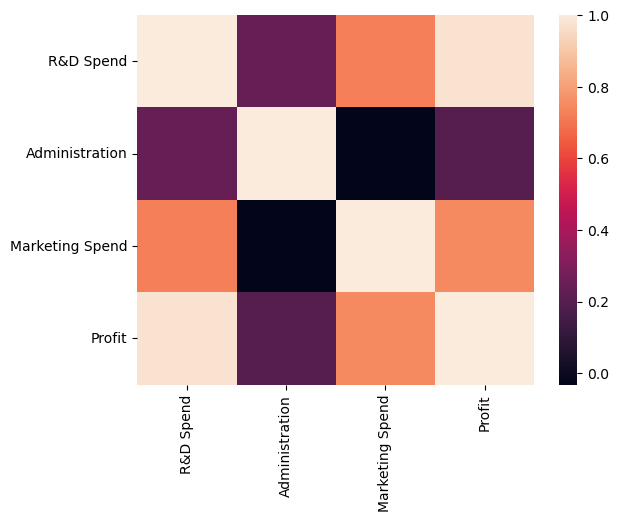

In [92]:
sns.heatmap(correlations)

<Axes: xlabel='R&D Spend', ylabel='Profit'>

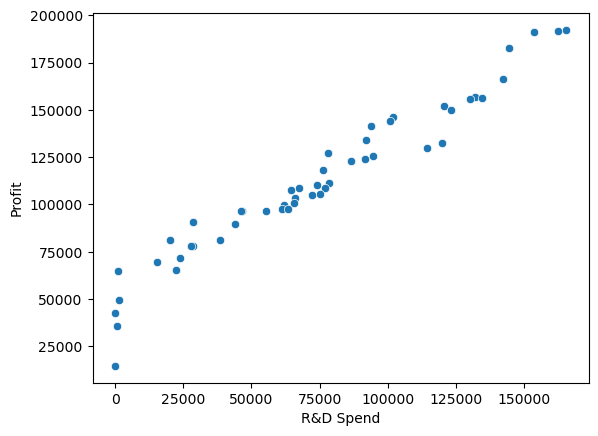

In [93]:
sns.scatterplot(x="R&D Spend",y="Profit",data=df)

In [94]:
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# df["State"] = le.fit_transform(df["State"])
# df.head()

In [95]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
state_dummy=ohe.fit_transform(df[["State"]]).toarray()
state_dummy


array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0

In [96]:
df_dummy = pd.get_dummies(df["State"], drop_first=True,dtype=int)
df_dummy.head()

,Florida,New York
0,0,1
1,0,0
2,1,0
3,0,1
4,1,0


In [97]:
df=pd.concat([df,df_dummy],axis=1)
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,Florida,New York
0,165349.20,136897.80,471784.10,New York,192261.83,0,1
1,162597.70,151377.59,443898.53,California,191792.06,0,0
2,153441.51,101145.55,407934.54,Florida,191050.39,1,0
3,144372.41,118671.85,383199.62,New York,182901.99,0,1
4,142107.34,91391.77,366168.42,Florida,166187.94,1,0


In [98]:
df.drop("State",axis=1,inplace=True)
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,Florida,New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


In [99]:
x=df.drop("Profit",axis=1)
y=df["Profit"]

In [100]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [101]:
from sklearn.preprocessing import StandardScaler
stand=StandardScaler()
x_train=stand.fit_transform(x_train)
x_test=stand.transform(x_test)

In [104]:
print("x_train_scaled shape:",x_train.mean())
print("x_test_scaled shape:",x_test.std())

x_train_scaled shape: -3.441691376337985e-17
x_test_scaled shape: 1.0209965513914543


In [106]:
from sklearn.linear_model import LinearRegression

In [108]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [109]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [112]:
mean_absolute_error(y_test,y_pred)

6961.477813275557

In [114]:
np.sqrt(mean_squared_error(y_test,y_pred))

9055.957323497809

In [115]:
r2_score(y_test,y_pred)

0.8987266414319838